In [3]:
# Data Handling
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
!pip install seaborn


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
# Importing the dataset
Development = pd.read_csv("HDI.csv")

# Display the first five rows
Development.head()

FileNotFoundError: [Errno 2] No such file or directory: 'HDI.csv'

In [5]:
# Importing the dataset
Development = pd.read_csv("Dataset/HDI.csv")

# Display the first five rows
Development.head()

FileNotFoundError: [Errno 2] No such file or directory: 'Dataset/HDI.csv'

In [6]:
import os

print("Current Working Directory:")
print(os.getcwd())

print("\nFiles and folders in the current directory:")
print(os.listdir())

Current Working Directory:
c:\Users\lokes\OneDrive\Documents\ML-0027-HUMAN DEVELOPMENT INDEX-202605\ML-0027-Human Development Index\Training

Files and folders in the current directory:
['HumDevIndex.ipynb']


In [7]:
import os

parent = os.path.dirname(os.getcwd())

print("Parent folder:", parent)
print(os.listdir(parent))

Parent folder: c:\Users\lokes\OneDrive\Documents\ML-0027-HUMAN DEVELOPMENT INDEX-202605\ML-0027-Human Development Index
['Dataset', 'Flask', 'Training']


In [8]:
import os

print(os.listdir("../Dataset"))

['HDI.csv']


In [9]:
Development = pd.read_csv("../Dataset/HDI.csv")
Development.head()

,ISO3,Country,Human Development Groups,UNDP Developing Regions,HDI Rank (2021),Human Development Index (1990),Human Development Index (1991),Human Development Index (1992),Human Development Index (1993),Human Development Index (1994),...,Material footprint per capita (tonnes) (2012),Material footprint per capita (tonnes) (2013),Material footprint per capita (tonnes) (2014),Material footprint per capita (tonnes) (2015),Material footprint per capita (tonnes) (2016),Material footprint per capita (tonnes) (2017),Material footprint per capita (tonnes) (2018),Material footprint per capita (tonnes) (2019),Material footprint per capita (tonnes) (2020),Material footprint per capita (tonnes) (2021)
0,AFG,Afghanistan,Low,SA,180.0,0.273,0.279,0.287,0.297,0.292,...,1.86,1.88,1.66,1.62,1.66,1.41,1.32,1.38,1.38,1.38
1,AGO,Angola,Medium,SSA,148.0,NaN,NaN,NaN,NaN,NaN,...,4.09,4.53,3.97,3.59,2.79,2.64,2.28,2.18,2.18,2.18
2,ALB,Albania,High,ECA,67.0,0.647,0.629,0.614,0.617,0.624,...,12.44,11.49,13.14,12.61,14.39,14.46,12.85,12.96,12.96,12.96
3,AND,Andorra,Very High,NaN,40.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ARE,United Arab Emirates,Very High,AS,26.0,0.728,0.739,0.742,0.748,0.755,...,49.56,49.68,55.49,59.76,64.95,75.61,65.97,68.95,68.95,68.95


In [10]:
Development.shape

(195, 880)

In [11]:
Development.columns

Index(['ISO3', 'Country', 'Human Development Groups',
       'UNDP Developing Regions', 'HDI Rank (2021)',
       'Human Development Index (1990)', 'Human Development Index (1991)',
       'Human Development Index (1992)', 'Human Development Index (1993)',
       'Human Development Index (1994)',
       ...
       'Material footprint per capita (tonnes) (2012)',
       'Material footprint per capita (tonnes) (2013)',
       'Material footprint per capita (tonnes) (2014)',
       'Material footprint per capita (tonnes) (2015)',
       'Material footprint per capita (tonnes) (2016)',
       'Material footprint per capita (tonnes) (2017)',
       'Material footprint per capita (tonnes) (2018)',
       'Material footprint per capita (tonnes) (2019)',
       'Material footprint per capita (tonnes) (2020)',
       'Material footprint per capita (tonnes) (2021)'],
      dtype='object', length=880)

In [12]:
Development.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Columns: 880 entries, ISO3 to Material footprint per capita (tonnes) (2021)
dtypes: float64(876), object(4)
memory usage: 1.3+ MB


In [13]:
Development.describe()

,HDI Rank (2021),Human Development Index (1990),Human Development Index (1991),Human Development Index (1992),Human Development Index (1993),Human Development Index (1994),Human Development Index (1995),Human Development Index (1996),Human Development Index (1997),Human Development Index (1998),...,Material footprint per capita (tonnes) (2012),Material footprint per capita (tonnes) (2013),Material footprint per capita (tonnes) (2014),Material footprint per capita (tonnes) (2015),Material footprint per capita (tonnes) (2016),Material footprint per capita (tonnes) (2017),Material footprint per capita (tonnes) (2018),Material footprint per capita (tonnes) (2019),Material footprint per capita (tonnes) (2020),Material footprint per capita (tonnes) (2021)
count,191.000000,141.000000,141.000000,141.000000,141.000000,141.000000,152.000000,152.000000,152.000000,152.000000,...,157.00000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000
mean,95.811518,0.599277,0.601979,0.604525,0.608504,0.613411,0.617625,0.623336,0.628599,0.634059,...,15.55535,15.675860,15.631146,15.637707,15.637834,15.798089,14.840000,15.019490,15.019490,15.019490
std,55.307333,0.164044,0.164100,0.164457,0.165456,0.166191,0.164990,0.165710,0.166592,0.167486,...,14.49240,14.930422,14.730498,15.063439,15.412834,15.739461,13.932553,14.644025,14.644025,14.644025
min,1.000000,0.216000,0.218000,0.222000,0.227000,0.232000,0.238000,0.243000,0.248000,0.256000,...,0.43000,0.420000,0.450000,0.560000,0.600000,0.610000,0.500000,0.470000,0.470000,0.470000
25%,48.500000,0.482000,0.484000,0.485000,0.485000,0.486000,0.486750,0.490750,0.492000,0.493000,...,4.53000,4.510000,4.350000,4.360000,4.420000,4.560000,4.590000,4.620000,4.620000,4.620000
50%,96.000000,0.628000,0.629000,0.627000,0.634000,0.639000,0.646500,0.653000,0.658000,0.664500,...,10.53000,10.370000,10.680000,10.020000,10.400000,10.740000,11.150000,10.620000,10.620000,10.620000
75%,143.500000,0.728000,0.729000,0.727000,0.731000,0.741000,0.745250,0.752000,0.759250,0.767000,...,20.90000,20.780000,20.750000,21.290000,19.790000,20.030000,18.960000,18.870000,18.870000,18.870000
max,191.000000,0.872000,0.873000,0.878000,0.880000,0.884000,0.885000,0.887000,0.890000,0.895000,...,74.56000,82.970000,81.100000,86.780000,83.510000,88.700000,71.160000,85.700000,85.700000,85.700000


In [14]:
Development.isnull().sum()

ISO3                                              0
Country                                           0
Human Development Groups                          4
UNDP Developing Regions                          44
HDI Rank (2021)                                   4
                                                 ..
Material footprint per capita (tonnes) (2017)    38
Material footprint per capita (tonnes) (2018)    38
Material footprint per capita (tonnes) (2019)    38
Material footprint per capita (tonnes) (2020)    38
Material footprint per capita (tonnes) (2021)    38
Length: 880, dtype: int64

In [15]:
Development.duplicated().sum()

np.int64(0)

In [16]:
# Creating a new DataFrame with the first 20 rows
data1 = Development.head(20)

# Display the first 20 rows
data1

,ISO3,Country,Human Development Groups,UNDP Developing Regions,HDI Rank (2021),Human Development Index (1990),Human Development Index (1991),Human Development Index (1992),Human Development Index (1993),Human Development Index (1994),...,Material footprint per capita (tonnes) (2012),Material footprint per capita (tonnes) (2013),Material footprint per capita (tonnes) (2014),Material footprint per capita (tonnes) (2015),Material footprint per capita (tonnes) (2016),Material footprint per capita (tonnes) (2017),Material footprint per capita (tonnes) (2018),Material footprint per capita (tonnes) (2019),Material footprint per capita (tonnes) (2020),Material footprint per capita (tonnes) (2021)
0,AFG,Afghanistan,Low,SA,180.0,0.273,0.279,0.287,0.297,0.292,...,1.86,1.88,1.66,1.62,1.66,1.41,1.32,1.38,1.38,1.38
1,AGO,Angola,Medium,SSA,148.0,NaN,NaN,NaN,NaN,NaN,...,4.09,4.53,3.97,3.59,2.79,2.64,2.28,2.18,2.18,2.18
2,ALB,Albania,High,ECA,67.0,0.647,0.629,0.614,0.617,0.624,...,12.44,11.49,13.14,12.61,14.39,14.46,12.85,12.96,12.96,12.96
3,AND,Andorra,Very High,NaN,40.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ARE,United Arab Emirates,Very High,AS,26.0,0.728,0.739,0.742,0.748,0.755,...,49.56,49.68,55.49,59.76,64.95,75.61,65.97,68.95,68.95,68.95
5,ARG,Argentina,Very High,LAC,47.0,0.723,0.730,0.735,0.739,0.744,...,15.69,16.74,16.57,17.85,16.95,18.75,16.88,15.81,15.81,15.81
6,ARM,Armenia,High,ECA,85.0,0.656,0.649,0.618,0.616,0.620,...,6.27,6.15,6.44,6.50,7.79,7.35,6.01,5.95,5.95,5.95
7,ATG,Antigua and Barbuda,High,LAC,71.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,AUS,Australia,Very High,NaN,5.0,0.865,0.867,0.869,0.873,0.873,...,49.09,45.97,47.80,46.91,46.32,48.27,47.70,46.82,46.82,46.82
9,AUT,Austria,Very High,NaN,25.0,0.825,0.829,0.835,0.840,0.845,...,27.26,27.32,27.48,26.40,26.89,25.62,25.39,24.62,24.62,24.62


In [17]:
# Display unique country names
data1["Country"].unique()

array(['Afghanistan', 'Angola', 'Albania', 'Andorra',
       'United Arab Emirates', 'Argentina', 'Armenia',
       'Antigua and Barbuda', 'Australia', 'Austria', 'Azerbaijan',
       'Burundi', 'Belgium', 'Benin', 'Burkina Faso', 'Bangladesh',
       'Bulgaria', 'Bahrain', 'Bahamas', 'Bosnia and Herzegovina'],
      dtype=object)

In [18]:
for col in Development.columns:
    if "school" in col.lower() or "life expectancy" in col.lower() or "human development index" in col.lower():
        print(col)

Human Development Index (1990)
Human Development Index (1991)
Human Development Index (1992)
Human Development Index (1993)
Human Development Index (1994)
Human Development Index (1995)
Human Development Index (1996)
Human Development Index (1997)
Human Development Index (1998)
Human Development Index (1999)
Human Development Index (2000)
Human Development Index (2001)
Human Development Index (2002)
Human Development Index (2003)
Human Development Index (2004)
Human Development Index (2005)
Human Development Index (2006)
Human Development Index (2007)
Human Development Index (2008)
Human Development Index (2009)
Human Development Index (2010)
Human Development Index (2011)
Human Development Index (2012)
Human Development Index (2013)
Human Development Index (2014)
Human Development Index (2015)
Human Development Index (2016)
Human Development Index (2017)
Human Development Index (2018)
Human Development Index (2019)
Human Development Index (2020)
Human Development Index (2021)
Life Exp

In [19]:
for col in Development.columns:
    if "(2021)" in col:
        print(col)

HDI Rank (2021)
Human Development Index (2021)
Life Expectancy at Birth (2021)
Expected Years of Schooling (2021)
Mean Years of Schooling (2021)
Gross National Income Per Capita (2021)
GDI Group (2021)
Gender Development Index (2021)
HDI female (2021)
Life Expectancy at Birth, female (2021)
Expected Years of Schooling, female (2021)
Mean Years of Schooling, female (2021)
Gross National Income Per Capita, female (2021)
HDI male (2021)
Life Expectancy at Birth, male (2021)
Expected Years of Schooling, male (2021)
Mean Years of Schooling, male (2021)
Gross National Income Per Capita, male (2021)
Inequality-adjusted Human Development Index (2021)
Coefficient of human inequality (2021)
Overall loss (%) (2021)
Inequality in life expectancy (2021)
Inequality in eduation (2021)
Inequality in income (2021)
GII Rank (2021)
Gender Inequality Index (2021)
Maternal Mortality Ratio (deaths per 100,000 live births) (2021)
Adolescent Birth Rate (births per 1,000 women ages 15-19) (2021)
Labour force p

In [20]:
# Creating a new DataFrame with the first 20 rows
data1 = Development.head(20)

# Display the first 20 rows
data1

,ISO3,Country,Human Development Groups,UNDP Developing Regions,HDI Rank (2021),Human Development Index (1990),Human Development Index (1991),Human Development Index (1992),Human Development Index (1993),Human Development Index (1994),...,Material footprint per capita (tonnes) (2012),Material footprint per capita (tonnes) (2013),Material footprint per capita (tonnes) (2014),Material footprint per capita (tonnes) (2015),Material footprint per capita (tonnes) (2016),Material footprint per capita (tonnes) (2017),Material footprint per capita (tonnes) (2018),Material footprint per capita (tonnes) (2019),Material footprint per capita (tonnes) (2020),Material footprint per capita (tonnes) (2021)
0,AFG,Afghanistan,Low,SA,180.0,0.273,0.279,0.287,0.297,0.292,...,1.86,1.88,1.66,1.62,1.66,1.41,1.32,1.38,1.38,1.38
1,AGO,Angola,Medium,SSA,148.0,NaN,NaN,NaN,NaN,NaN,...,4.09,4.53,3.97,3.59,2.79,2.64,2.28,2.18,2.18,2.18
2,ALB,Albania,High,ECA,67.0,0.647,0.629,0.614,0.617,0.624,...,12.44,11.49,13.14,12.61,14.39,14.46,12.85,12.96,12.96,12.96
3,AND,Andorra,Very High,NaN,40.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ARE,United Arab Emirates,Very High,AS,26.0,0.728,0.739,0.742,0.748,0.755,...,49.56,49.68,55.49,59.76,64.95,75.61,65.97,68.95,68.95,68.95
5,ARG,Argentina,Very High,LAC,47.0,0.723,0.730,0.735,0.739,0.744,...,15.69,16.74,16.57,17.85,16.95,18.75,16.88,15.81,15.81,15.81
6,ARM,Armenia,High,ECA,85.0,0.656,0.649,0.618,0.616,0.620,...,6.27,6.15,6.44,6.50,7.79,7.35,6.01,5.95,5.95,5.95
7,ATG,Antigua and Barbuda,High,LAC,71.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,AUS,Australia,Very High,NaN,5.0,0.865,0.867,0.869,0.873,0.873,...,49.09,45.97,47.80,46.91,46.32,48.27,47.70,46.82,46.82,46.82
9,AUT,Austria,Very High,NaN,25.0,0.825,0.829,0.835,0.840,0.845,...,27.26,27.32,27.48,26.40,26.89,25.62,25.39,24.62,24.62,24.62


In [21]:
# Display unique country names
data1["Country"].unique()

array(['Afghanistan', 'Angola', 'Albania', 'Andorra',
       'United Arab Emirates', 'Argentina', 'Armenia',
       'Antigua and Barbuda', 'Australia', 'Austria', 'Azerbaijan',
       'Burundi', 'Belgium', 'Benin', 'Burkina Faso', 'Bangladesh',
       'Bulgaria', 'Bahrain', 'Bahamas', 'Bosnia and Herzegovina'],
      dtype=object)

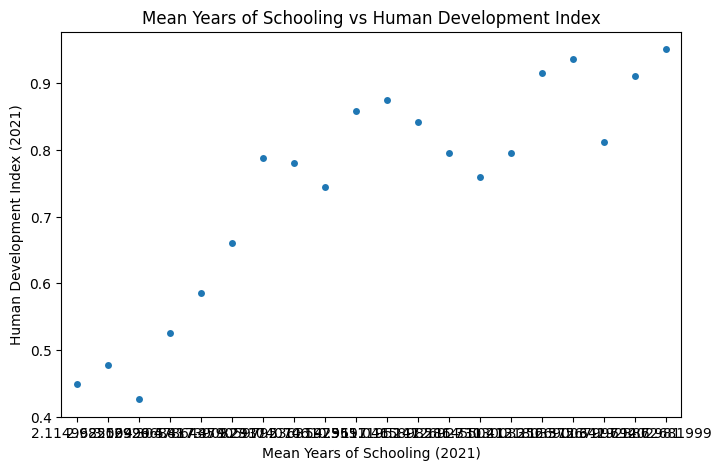

In [22]:
plt.figure(figsize=(8,5))

sns.stripplot(
    x=data1["Mean Years of Schooling (2021)"],
    y=data1["Human Development Index (2021)"]
)

plt.title("Mean Years of Schooling vs Human Development Index")
plt.xlabel("Mean Years of Schooling (2021)")
plt.ylabel("Human Development Index (2021)")

plt.show()

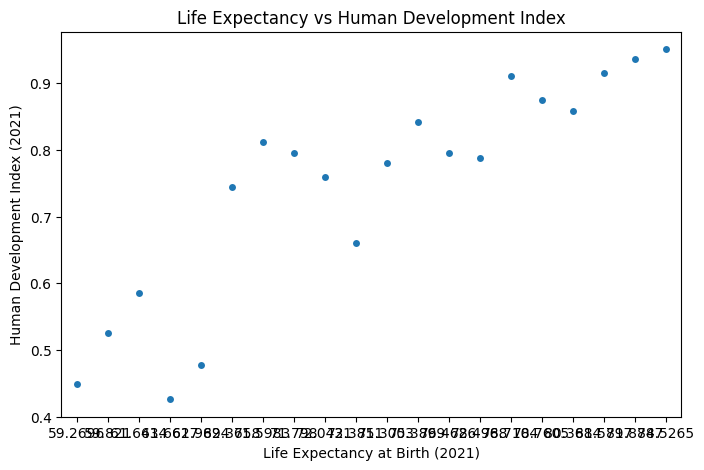

In [23]:
plt.figure(figsize=(8,5))

sns.stripplot(
    x=data1["Life Expectancy at Birth (2021)"],
    y=data1["Human Development Index (2021)"]
)

plt.title("Life Expectancy vs Human Development Index")
plt.xlabel("Life Expectancy at Birth (2021)")
plt.ylabel("Human Development Index (2021)")

plt.show()

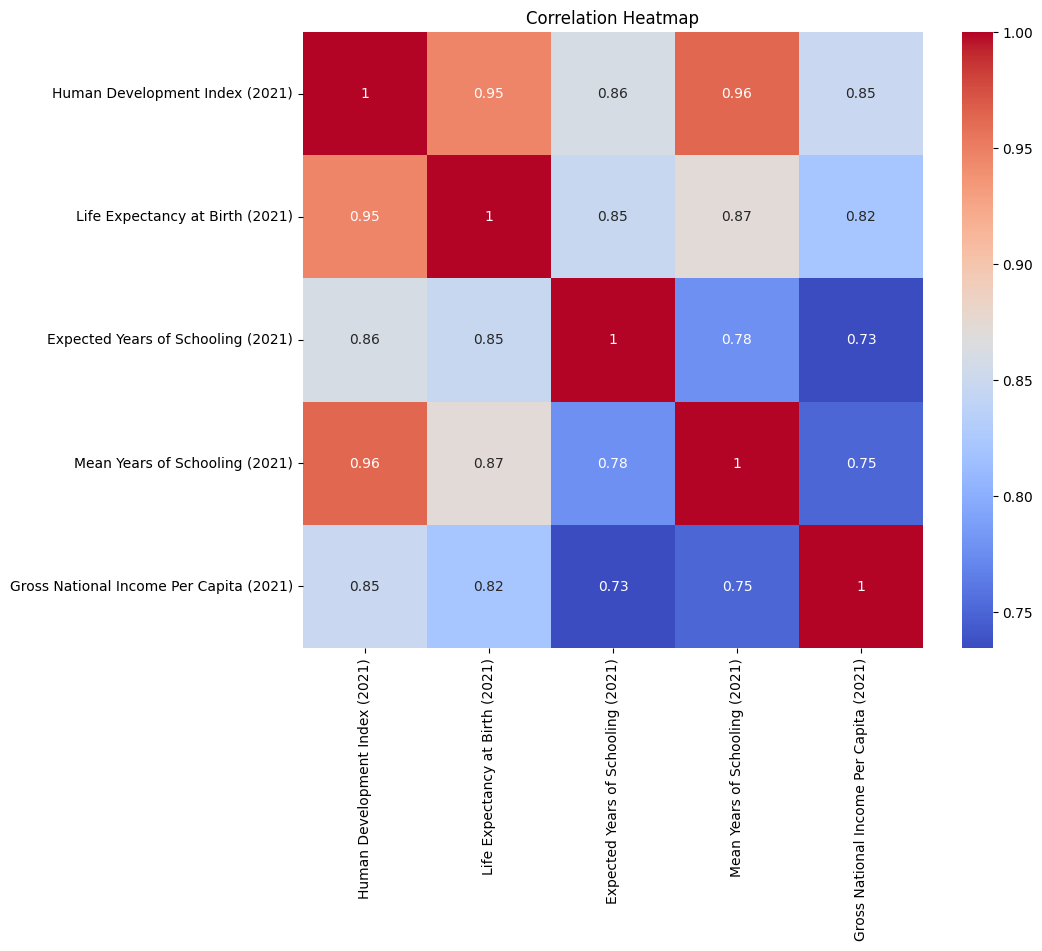

In [24]:
plt.figure(figsize=(10,8))

corr = data1[[
    "Human Development Index (2021)",
    "Life Expectancy at Birth (2021)",
    "Expected Years of Schooling (2021)",
    "Mean Years of Schooling (2021)",
    "Gross National Income Per Capita (2021)"
]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

In [25]:
# Selecting the independent variables (features)
X = Development[[
    "Life Expectancy at Birth (2021)",
    "Expected Years of Schooling (2021)",
    "Mean Years of Schooling (2021)",
    "Gross National Income Per Capita (2021)"
]]

# Selecting the dependent variable (target)
Y = Development["Human Development Index (2021)"]

In [26]:
X.head()

,Life Expectancy at Birth (2021),Expected Years of Schooling (2021),Mean Years of Schooling (2021),Gross National Income Per Capita (2021)
0,61.9824,10.263844,2.985070,1824.190915
1,61.6434,12.172100,5.417391,5465.617791
2,76.4626,14.448000,11.286455,14131.110390
3,80.3684,13.300239,10.555120,51166.626610
4,78.7104,15.717690,12.694030,62573.591810


In [27]:
Y.head()

0    0.478
1    0.586
2    0.796
3    0.858
4    0.911
Name: Human Development Index (2021), dtype: float64

In [28]:
# Selecting the independent variables (features)
X = Development[[
    "Life Expectancy at Birth (2021)",
    "Expected Years of Schooling (2021)",
    "Mean Years of Schooling (2021)",
    "Gross National Income Per Capita (2021)"
]]

# Selecting the dependent variable (target)
Y = Development["Human Development Index (2021)"]

In [29]:
print("Features:")
print(X.head())

print("\nTarget:")
print(Y.head())

Features:
   Life Expectancy at Birth (2021)  Expected Years of Schooling (2021)  \
0                          61.9824                           10.263844   
1                          61.6434                           12.172100   
2                          76.4626                           14.448000   
3                          80.3684                           13.300239   
4                          78.7104                           15.717690   

   Mean Years of Schooling (2021)  Gross National Income Per Capita (2021)  
0                        2.985070                              1824.190915  
1                        5.417391                              5465.617791  
2                       11.286455                             14131.110390  
3                       10.555120                             51166.626610  
4                       12.694030                             62573.591810  

Target:
0    0.478
1    0.586
2    0.796
3    0.858
4    0.911
Name: Human Develop

In [30]:
# Selecting the independent variables (X)
X = Development[[
    "Life Expectancy at Birth (2021)",
    "Expected Years of Schooling (2021)",
    "Mean Years of Schooling (2021)",
    "Gross National Income Per Capita (2021)"
]]

# Selecting the dependent variable (Y)
Y = Development["Human Development Index (2021)"]

In [31]:
print("Independent Variables (X)")
X.head()

Independent Variables (X)


,Life Expectancy at Birth (2021),Expected Years of Schooling (2021),Mean Years of Schooling (2021),Gross National Income Per Capita (2021)
0,61.9824,10.263844,2.985070,1824.190915
1,61.6434,12.172100,5.417391,5465.617791
2,76.4626,14.448000,11.286455,14131.110390
3,80.3684,13.300239,10.555120,51166.626610
4,78.7104,15.717690,12.694030,62573.591810


In [32]:
print("Dependent Variable (Y)")
Y.head()

Dependent Variable (Y)


0    0.478
1    0.586
2    0.796
3    0.858
4    0.911
Name: Human Development Index (2021), dtype: float64

In [33]:
# Check the number of missing values in each independent variable
X.isnull().sum()

Life Expectancy at Birth (2021)            0
Expected Years of Schooling (2021)         2
Mean Years of Schooling (2021)             4
Gross National Income Per Capita (2021)    2
dtype: int64

In [34]:
# Fill missing values with the mean of each column
X = X.fillna(X.mean())

In [35]:
# Check again for missing values
X.isnull().sum()

Life Expectancy at Birth (2021)            0
Expected Years of Schooling (2021)         0
Mean Years of Schooling (2021)             0
Gross National Income Per Capita (2021)    0
dtype: int64

In [36]:
# Splitting the dataset into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

In [37]:
print("Training Features Shape :", X_train.shape)
print("Testing Features Shape  :", X_test.shape)
print("Training Target Shape   :", Y_train.shape)
print("Testing Target Shape    :", Y_test.shape)

Training Features Shape : (156, 4)
Testing Features Shape  : (39, 4)
Training Target Shape   : (156,)
Testing Target Shape    : (39,)


In [38]:
Import and instantiate the Linear Regression model to build a predictive machine learning model. The model is trained using the prepared training dataset so that it can learn the relationship between the input features and the target variable.

![image1.png](https://skillwalletapp.s3.amazonaws.com/nDxebdryD/image1.png)

Testing the test field form the split:

![image.png](https://skillwalletapp.s3.amazonaws.com/K6pkBZm3v/image.png)


SyntaxError: invalid syntax (4014666577.py, line 1)

In [39]:
from sklearn.linear_model import LinearRegression

In [40]:
# Creating the Linear Regression model
model = LinearRegression()

In [41]:
# Training the model using the training data
model.fit(X_train, Y_train)

ValueError: Input y contains NaN.

In [42]:
Y.isnull().sum()

np.int64(4)

In [43]:
# Combine X and Y
data = pd.concat([X, Y], axis=1)

# Remove rows where the target is missing
data = data.dropna(subset=["Human Development Index (2021)"])

# Split back into X and Y
X = data.drop(columns=["Human Development Index (2021)"])
Y = data["Human Development Index (2021)"]

In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

In [45]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, Y_train)

LinearRegression()

In [46]:
Y.isnull().sum()

np.int64(0)

In [47]:
Y_train.isnull().sum()

np.int64(0)

In [48]:
print(X.shape)
print(Y.shape)

print(X_train.shape)
print(Y_train.shape)

(191, 4)
(191,)
(152, 4)
(152,)


In [49]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 191 entries, 0 to 194
Data columns (total 4 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Life Expectancy at Birth (2021)          191 non-null    float64
 1   Expected Years of Schooling (2021)       191 non-null    float64
 2   Mean Years of Schooling (2021)           191 non-null    float64
 3   Gross National Income Per Capita (2021)  191 non-null    float64
dtypes: float64(4)
memory usage: 7.5 KB


In [50]:
Y.info()

<class 'pandas.core.series.Series'>
Index: 191 entries, 0 to 194
Series name: Human Development Index (2021)
Non-Null Count  Dtype  
--------------  -----  
191 non-null    float64
dtypes: float64(1)
memory usage: 3.0 KB


In [51]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

In [52]:
Y_train.isnull().sum()

np.int64(0)

In [53]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, Y_train)

LinearRegression()

In [54]:
Y_train.isnull().sum()

np.int64(0)

In [55]:
print(X.shape)
print(Y.shape)

(191, 4)
(191,)


In [56]:
print(X_train.shape)
print(Y_train.shape)

(152, 4)
(152,)


In [57]:
print(X.isnull().sum())

Life Expectancy at Birth (2021)            0
Expected Years of Schooling (2021)         0
Mean Years of Schooling (2021)             0
Gross National Income Per Capita (2021)    0
dtype: int64


In [58]:
print(X.dtypes)

Life Expectancy at Birth (2021)            float64
Expected Years of Schooling (2021)         float64
Mean Years of Schooling (2021)             float64
Gross National Income Per Capita (2021)    float64
dtype: object


In [59]:
print(Y.dtype)

float64


In [60]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Split the data
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

# Create and train the model
model = LinearRegression()
model.fit(X_train, Y_train)

print("Model trained successfully!")

Model trained successfully!


In [61]:
print(Y.head())

0    0.478
1    0.586
2    0.796
3    0.858
4    0.911
Name: Human Development Index (2021), dtype: float64


In [62]:
print(Y.dtype)

float64


In [63]:
print(X.dtypes)

Life Expectancy at Birth (2021)            float64
Expected Years of Schooling (2021)         float64
Mean Years of Schooling (2021)             float64
Gross National Income Per Capita (2021)    float64
dtype: object


In [64]:
print("X shape:", X.shape)
print("Y shape:", Y.shape)

print("\nNaN in X:")
print(X.isna().sum())

print("\nNaN in Y:")
print(Y.isna().sum())

print("\nInfinity in X:")
print(np.isinf(X).sum())

print("\nInfinity in Y:")
print(np.isinf(Y).sum())

X shape: (191, 4)
Y shape: (191,)

NaN in X:
Life Expectancy at Birth (2021)            0
Expected Years of Schooling (2021)         0
Mean Years of Schooling (2021)             0
Gross National Income Per Capita (2021)    0
dtype: int64

NaN in Y:
0

Infinity in X:
Life Expectancy at Birth (2021)            0
Expected Years of Schooling (2021)         0
Mean Years of Schooling (2021)             0
Gross National Income Per Capita (2021)    0
dtype: int64

Infinity in Y:
0


In [65]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Split the data
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

print("Y_train NaN:", Y_train.isna().sum())
print("Y_test NaN:", Y_test.isna().sum())

model = LinearRegression()
model.fit(X_train, Y_train)

print("Model trained successfully!")

Y_train NaN: 0
Y_test NaN: 0
Model trained successfully!


In [66]:
# Predicting the target values for the test dataset
Y_pred = model.predict(X_test)

In [67]:
Y_pred

array([0.49934346, 0.53987054, 0.71530562, 0.4931097 , 0.68042162,
       0.67111178, 0.90941976, 0.7755583 , 0.95433843, 0.42904406,
       0.87472271, 0.43225764, 0.78960798, 0.97161671, 0.65816534,
       0.74547713, 0.79337957, 0.51182025, 0.39388825, 0.89161716,
       0.97236295, 0.79931717, 0.53838309, 0.52400236, 0.80847424,
       0.75719323, 0.57810162, 0.77387469, 0.47930342, 0.83222196,
       0.73826953, 0.91690117, 0.84557668, 0.7973612 , 0.73708989,
       0.58257105, 0.76385548, 0.75167646, 0.74571066])

In [68]:
comparison = pd.DataFrame({
    "Actual HDI": Y_test.values,
    "Predicted HDI": Y_pred
})

comparison.head(10)

,Actual HDI,Predicted HDI
0,0.477,0.499343
1,0.535,0.539871
2,0.730,0.715306
3,0.483,0.493110
4,0.706,0.680422
5,0.661,0.671112
6,0.916,0.909420
7,0.795,0.775558
8,0.941,0.954338
9,0.400,0.429044


In [69]:
# Predicting the target values for the test dataset
Y_pred = model.predict(X_test)

In [70]:
Y_pred

array([0.49934346, 0.53987054, 0.71530562, 0.4931097 , 0.68042162,
       0.67111178, 0.90941976, 0.7755583 , 0.95433843, 0.42904406,
       0.87472271, 0.43225764, 0.78960798, 0.97161671, 0.65816534,
       0.74547713, 0.79337957, 0.51182025, 0.39388825, 0.89161716,
       0.97236295, 0.79931717, 0.53838309, 0.52400236, 0.80847424,
       0.75719323, 0.57810162, 0.77387469, 0.47930342, 0.83222196,
       0.73826953, 0.91690117, 0.84557668, 0.7973612 , 0.73708989,
       0.58257105, 0.76385548, 0.75167646, 0.74571066])

In [71]:
comparison = pd.DataFrame({
    "Actual HDI": Y_test.values,
    "Predicted HDI": Y_pred
})

comparison.head(10)

,Actual HDI,Predicted HDI
0,0.477,0.499343
1,0.535,0.539871
2,0.730,0.715306
3,0.483,0.493110
4,0.706,0.680422
5,0.661,0.671112
6,0.916,0.909420
7,0.795,0.775558
8,0.941,0.954338
9,0.400,0.429044


In [72]:
import pickle

In [73]:
# Save the trained model to a file
with open("HDI_Model.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model saved successfully!")

Model saved successfully!


In [74]:
# Load the saved model
with open("HDI_Model.pkl", "rb") as file:
    loaded_model = pickle.load(file)

print("Model loaded successfully!")

Model loaded successfully!


In [75]:
# Predict using the loaded model
prediction = loaded_model.predict(X_test)

print(prediction[:5])

[0.49934346 0.53987054 0.71530562 0.4931097  0.68042162]


In [76]:
from flask import Flask, render_template, request
import pickle
import numpy as np

In [77]:
app = Flask(__name__)

# Load the trained model
model = pickle.load(open("HDI_Model.pkl", "rb"))

In [78]:
@app.route("/")
def home():
    return render_template("home.html")

In [79]:
@app.route("/predict", methods=["POST"])
def predict():

    # Get values entered by the user
    features = [float(x) for x in request.form.values()]

    # Convert to NumPy array
    final_features = np.array([features])

    # Predict HDI
    prediction = model.predict(final_features)

    output = round(prediction[0], 3)

    return render_template(
        "index.html",
        prediction_text=f"Predicted Human Development Index (HDI): {output}"
    )

In [80]:
if __name__ == "__main__":
    app.run(debug=True)

 * Serving Flask app '__main__'
 * Debug mode: on


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
 * Restarting with watchdog (windowsapi)


SystemExit: 1